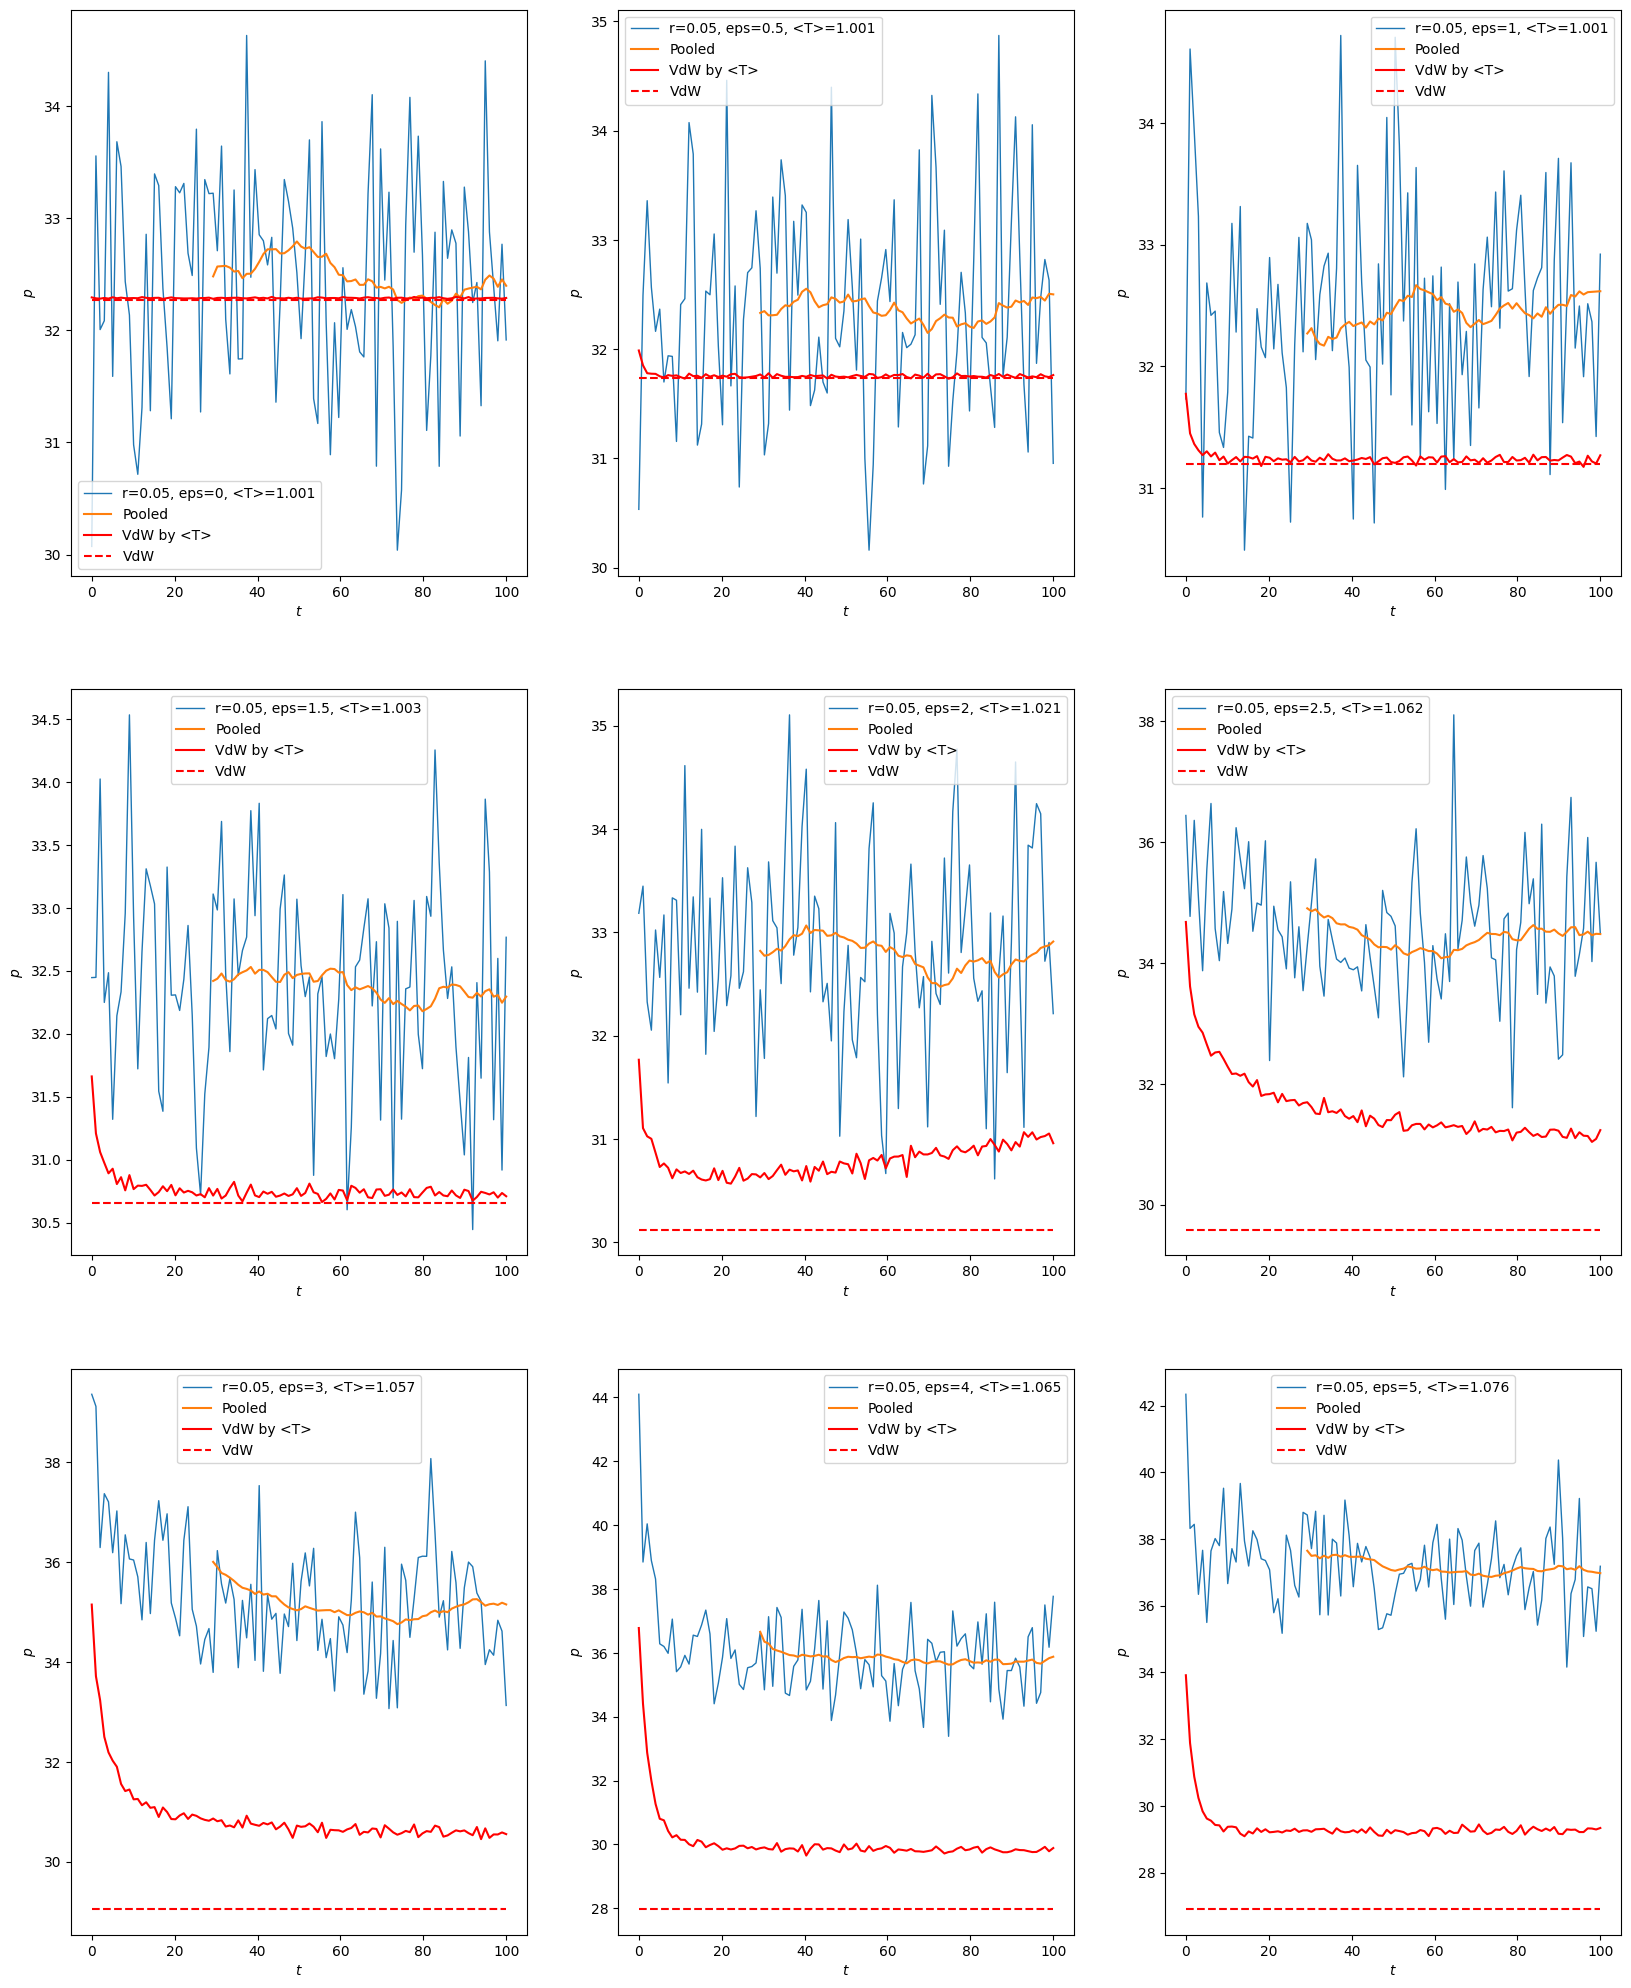

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
def pressure_vdw(r, n, T, l_j_epsilon):
    return n * T / (1 - 2 * n * np.pi * r ** 3 / 3) - 2 * np.pi * r**3 * 4 * l_j_epsilon * n**2 / 3

def pressure_vdw_test(r, n, T, l_j_epsilon):
    return n * T / (1 - 2 * n * np.pi * r ** 3 / 3) - 2 * np.pi * r**3 * 4 * l_j_epsilon * n**2 / 3
    # return n * T + 2 * np.pi * r**3 * (T - 4 * l_j_epsilon) * n**2 / 3

pressures = []
rs = []
energies = []
eps = [0, 0.5, 1, 1.5, 2, 2.5, 3, 4, 5]
dirs = []
timeLists = []

for d in os.listdir('.'):
    if os.path.isdir(d) and '20250902_215000' <= d[:15] <= '20250902_222000':
        dirs.append(d)
        r = float(d.split('r')[-1])
        rs.append(r)
        fs = os.listdir(os.path.join('.', d))
        assert "config.json" in fs and "pressure.npy" in fs, f"Missing files in {d}"
        pressures.append(np.load(os.path.join('.', d, "pressure.npy")))
        energies.append(np.load(os.path.join('.', d, "mean_v2.npy")) * 200 / 3)
        steps = np.load(os.path.join('.', d, "steps.npy"))
        timeLists.append(np.linspace(steps.min(), steps.max(), len(pressures[-1])))
assert len(pressures) == len(rs) == len(energies) == len(eps)
assert sorted(dirs) == dirs
Ts = [e[-100:].mean() for e in energies]
fig, axs = plt.subplots(3, 3, figsize=(20, 25))
for i in range(len(pressures)):
    ax = axs[i // 3, i % 3]
    ax.plot(timeLists[i], pressures[i], label=f"r={rs[i]}, eps={eps[i]}, <T>={Ts[i]:.3f}", linewidth=1)
    w = 30
    ax.plot(timeLists[i][w-1:], np.convolve(pressures[i], np.ones(w), "valid") / w, label='Pooled')
    ax.plot(timeLists[i], pressure_vdw_test(0.05, 32, energies[i], eps[i]), label='VdW by <T>', color='r')
    ax.plot(timeLists[i], pressure_vdw_test(0.05, 32, np.ones_like(timeLists[i]), eps[i]), '--', label='VdW', color='r')
    # ax.plot(timeLists[i], pressure_vdw(0.1, 32, np.ones_like(timeLists[i]), eps[i]), '--', label='VdW', color='grey')
    ax.legend()
    ax.set_xlabel("$t$")
    ax.set_ylabel("$p$")

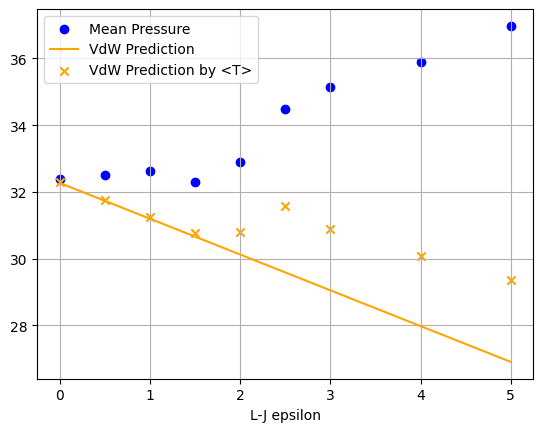

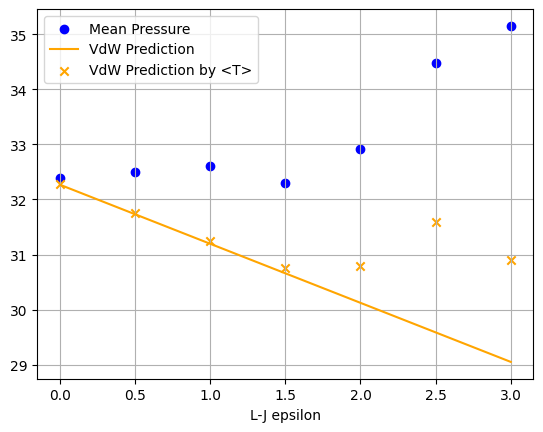

In [42]:
plt.scatter(eps, [p[-30:].mean() for p in pressures], label='Mean Pressure', color='blue')
plt.plot(np.linspace(0, 5, 100), pressure_vdw_test(0.05, 32, 1, np.linspace(0, 5, 100)), label='VdW Prediction', color='orange')
plt.scatter(np.array(eps), pressure_vdw_test(0.05, 32, np.array(Ts), np.array(eps)), label='VdW Prediction by <T>', marker='x', color='orange')
plt.legend()
plt.grid()
plt.xlabel("L-J epsilon")
plt.show()
plt.scatter(eps[:-2], [p[-30:].mean() for p in pressures[:-2]], label='Mean Pressure', color='blue')
plt.plot(np.linspace(0, max(eps[:-2]), 100), pressure_vdw_test(0.05, 32, 1, np.linspace(0, max(eps[:-2]), 100)), label='VdW Prediction', color='orange')
plt.scatter(np.array(eps[:-2]), pressure_vdw_test(0.05, 32, np.array(Ts[:-2]), np.array(eps[:-2])), label='VdW Prediction by <T>', marker='x', color='orange')
plt.legend()
plt.grid()
plt.xlabel("L-J epsilon")
plt.show()

In [43]:
pressure_vdw(0.1, 32, 1, 3)

8.56279542339346

In [44]:
# check if sorted
sorted(dirs) == dirs, dirs

(True,
 ['20250902_215435_929583_984r0.05',
  '20250902_215702_592845_585r0.05',
  '20250902_215854_754062_688r0.05',
  '20250902_220047_199599_935r0.05',
  '20250902_220241_344014_406r0.05',
  '20250902_220437_095479_895r0.05',
  '20250902_220639_023835_464r0.05',
  '20250902_220837_635444_307r0.05',
  '20250902_221032_702019_408r0.05'])

In [45]:
from pdf2image import convert_from_path
for i in range(len(dirs)):
    if not os.path.exists(os.path.join('.', 'EPS' + str(eps[i]) + 'r0.05points.png')):
        pages = convert_from_path(os.path.join('.', dirs[i], 'points.pdf'), 300)
        assert len(pages) == 1
        pages[0].save(os.path.join('.', 'EPS' + str(eps[i]) + 'r0.05points.png'), 'PNG')